In [2]:
import pandas as pd
import numpy as np
from numpy import r_
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Load dataset
data = pd.read_csv("Loan Eligibility Prediction.csv")

In [4]:
# Show first 5 rows
data.head()

,Customer_ID,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,569,Female,No,0,Graduate,No,2378,0.0,9,360,1,Urban,N
1,15,Male,Yes,2,Graduate,No,1299,1086.0,17,120,1,Urban,Y
2,95,Male,No,0,Not Graduate,No,3620,0.0,25,120,1,Semiurban,Y
3,134,Male,Yes,0,Graduate,Yes,3459,0.0,25,120,1,Semiurban,Y
4,556,Male,Yes,1,Graduate,No,5468,1032.0,26,360,1,Semiurban,Y


In [5]:
data.shape

(614, 13)

In [6]:
data.columns

Index(['Customer_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'Applicant_Income', 'Coapplicant_Income',
       'Loan_Amount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area',
       'Loan_Status'],
      dtype='object')

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         614 non-null    int64  
 1   Gender              614 non-null    object 
 2   Married             614 non-null    object 
 3   Dependents          614 non-null    int64  
 4   Education           614 non-null    object 
 5   Self_Employed       614 non-null    object 
 6   Applicant_Income    614 non-null    int64  
 7   Coapplicant_Income  614 non-null    float64
 8   Loan_Amount         614 non-null    int64  
 9   Loan_Amount_Term    614 non-null    int64  
 10  Credit_History      614 non-null    int64  
 11  Property_Area       614 non-null    object 
 12  Loan_Status         614 non-null    object 
dtypes: float64(1), int64(6), object(6)
memory usage: 62.5+ KB


In [8]:
data.describe()

,Customer_ID,Dependents,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,307.500000,0.856678,5403.459283,1621.245798,142.022801,338.892508,0.850163
std,177.390811,1.216651,6109.041673,2926.248369,87.083089,69.716355,0.357203
min,1.000000,0.000000,150.000000,0.000000,9.000000,12.000000,0.000000
25%,154.250000,0.000000,2877.500000,0.000000,98.000000,360.000000,1.000000
50%,307.500000,0.000000,3812.500000,1188.500000,125.000000,360.000000,1.000000
75%,460.750000,2.000000,5795.000000,2297.250000,164.750000,360.000000,1.000000
max,614.000000,4.000000,81000.000000,41667.000000,700.000000,480.000000,1.000000


In [9]:
pd.crosstab(data['Gender'],data['Loan_Status'],margins=True)

Loan_Status,N,Y,All
Gender,,,
Female,37,78,115
Male,155,344,499
All,192,422,614


<Axes: >

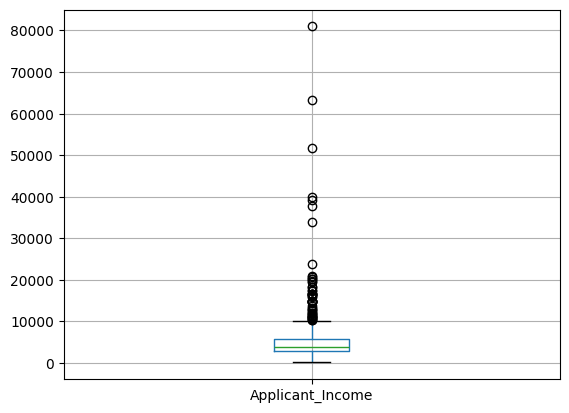

In [10]:
data.boxplot(column='Applicant_Income')

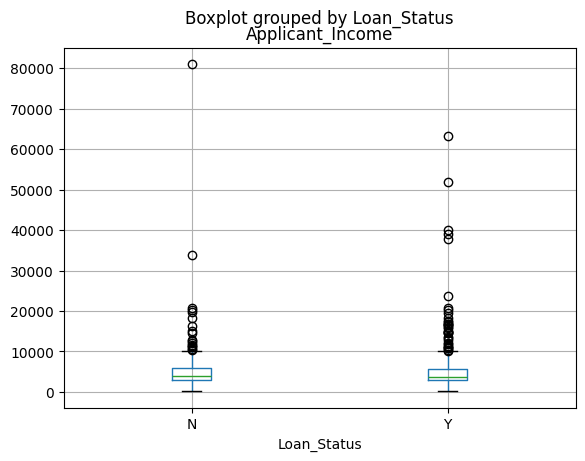

In [11]:
data.boxplot(column='Applicant_Income',by="Loan_Status")
plt.show()

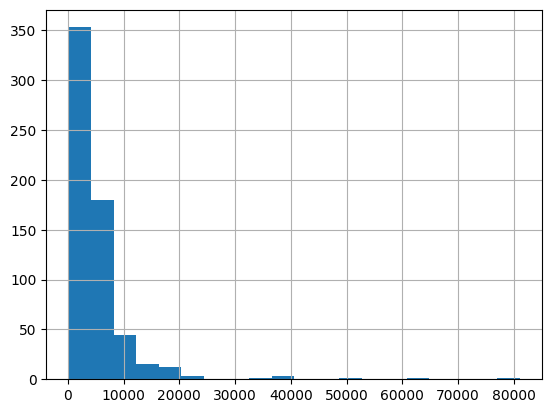

In [12]:
data['Applicant_Income'].hist(bins=20)
plt.show()

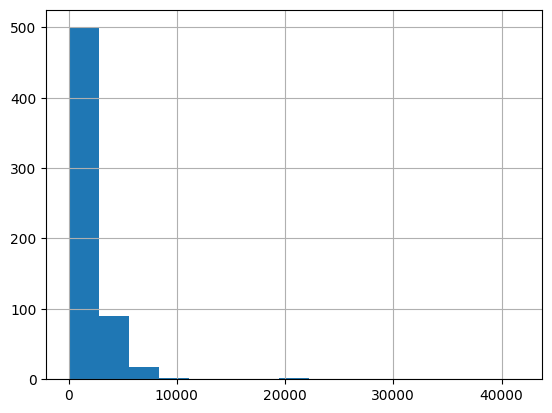

In [13]:
data['Coapplicant_Income'].hist(bins=15)
plt.show()

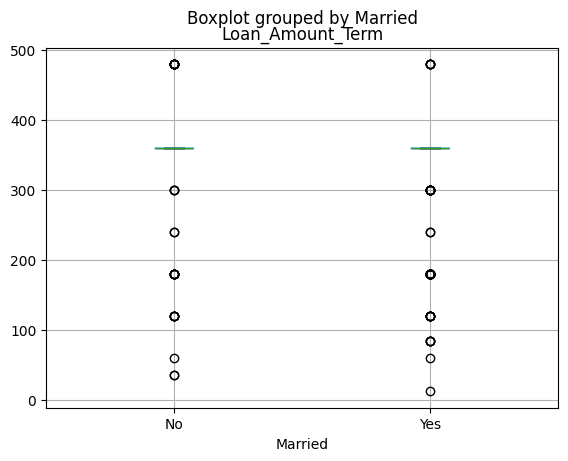

In [14]:
data.boxplot(column='Loan_Amount_Term',by="Married")
plt.show()


In [15]:
data.head()

,Customer_ID,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,569,Female,No,0,Graduate,No,2378,0.0,9,360,1,Urban,N
1,15,Male,Yes,2,Graduate,No,1299,1086.0,17,120,1,Urban,Y
2,95,Male,No,0,Not Graduate,No,3620,0.0,25,120,1,Semiurban,Y
3,134,Male,Yes,0,Graduate,Yes,3459,0.0,25,120,1,Semiurban,Y
4,556,Male,Yes,1,Graduate,No,5468,1032.0,26,360,1,Semiurban,Y


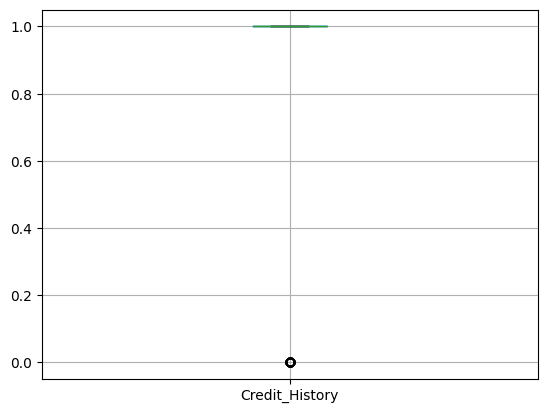

In [16]:
data.boxplot(column='Credit_History')
plt.show()

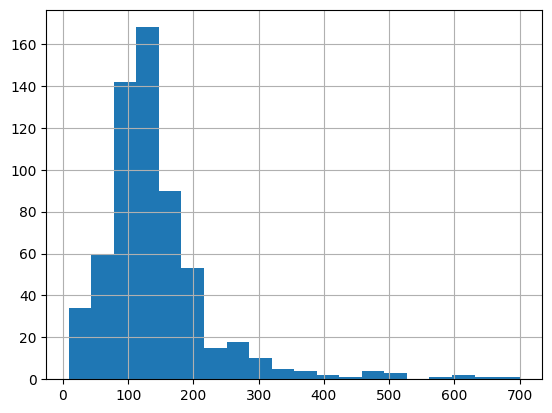

In [17]:
data['Loan_Amount'].hist(bins=20)
plt.show()

c:\Users\HELLO\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


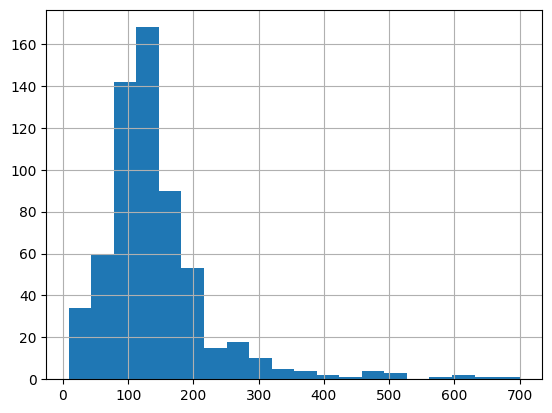

In [18]:
data['Loan_Amount_Term']=np.log(data['Coapplicant_Income'])
data['Loan_Amount'].hist(bins=20)
plt.show()

In [19]:
data['Loan_Status'].value_counts()
"""
Y → Approved

N → Not Approved

"""

'\nY → Approved\n\nN → Not Approved\n\n'

In [20]:
data.isnull().sum()

Customer_ID           0
Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
Applicant_Income      0
Coapplicant_Income    0
Loan_Amount           0
Loan_Amount_Term      0
Credit_History        0
Property_Area         0
Loan_Status           0
dtype: int64

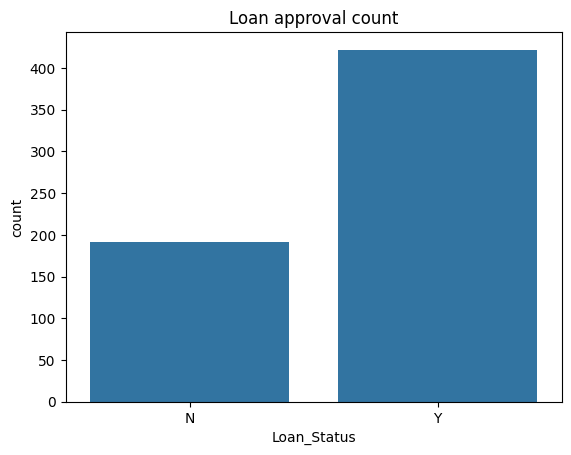

In [21]:
# Loan Status count
sns.countplot(x='Loan_Status', data=data)
plt.title('Loan approval count')
plt.show()

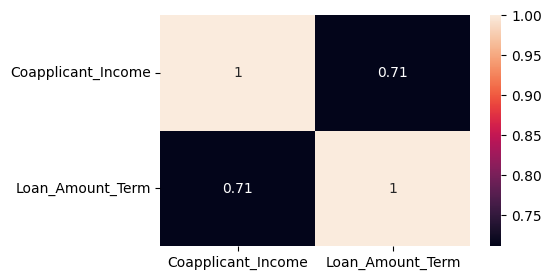

In [22]:
# Correlation heatmap
numeric_data=data.select_dtypes(include=['float64'])
plt.figure(figsize=(5,3))
sns.heatmap(numeric_data.corr(), annot=True)
plt.show()

In [23]:
data['Gender'].fillna(data['Gender'].mode(),inplace=True)

C:\Users\HELLO\AppData\Local\Temp\ipykernel_6988\2732842322.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Gender'].fillna(data['Gender'].mode(),inplace=True)


In [24]:
data['Married'].fillna(data['Married'].mode(),inplace=True)

C:\Users\HELLO\AppData\Local\Temp\ipykernel_6988\3311837877.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Married'].fillna(data['Married'].mode(),inplace=True)


In [25]:
data['Dependents'].fillna(data['Dependents'].mode(),inplace=True)

C:\Users\HELLO\AppData\Local\Temp\ipykernel_6988\1172323229.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Dependents'].fillna(data['Dependents'].mode(),inplace=True)


In [26]:
data['Self_Employed'].fillna(data['Self_Employed'].mode(),inplace=True)

C:\Users\HELLO\AppData\Local\Temp\ipykernel_6988\3421594596.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Self_Employed'].fillna(data['Self_Employed'].mode(),inplace=True)


In [27]:
data.Loan_Amount=data.Loan_Amount.fillna(data.Loan_Amount.mean())
data.Loan_Amount_Term=data.Loan_Amount_Term.fillna(data.Loan_Amount_Term.mean())

In [28]:
data['Loan_Amount_Term'].fillna(data['Loan_Amount_Term'].mode(),inplace=True)

C:\Users\HELLO\AppData\Local\Temp\ipykernel_6988\2255247062.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Loan_Amount_Term'].fillna(data['Loan_Amount_Term'].mode(),inplace=True)


In [29]:
data.isnull().sum()

Customer_ID           0
Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
Applicant_Income      0
Coapplicant_Income    0
Loan_Amount           0
Loan_Amount_Term      0
Credit_History        0
Property_Area         0
Loan_Status           0
dtype: int64

In [30]:
data['Total_Income']=data['Applicant_Income']+data['Coapplicant_Income']
data['Total_Income_Log']=np.log(data['Total_Income'])
#A new column Total_Income is created in the dataset (data).
#Creates another new column Total_Income_Log
#Applies logarithmic transformation using np.log()

In [31]:
data.columns

Index(['Customer_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'Applicant_Income', 'Coapplicant_Income',
       'Loan_Amount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area',
       'Loan_Status', 'Total_Income', 'Total_Income_Log'],
      dtype='object')

In [32]:
data['Total_Income'].head()

0    2378.0
1    2385.0
2    3620.0
3    3459.0
4    6500.0
Name: Total_Income, dtype: float64

In [33]:
data['Total_Income_Log'].tail()

609    8.422883
610    8.819813
611    8.799812
612    8.490233
613    8.732305
Name: Total_Income_Log, dtype: float64

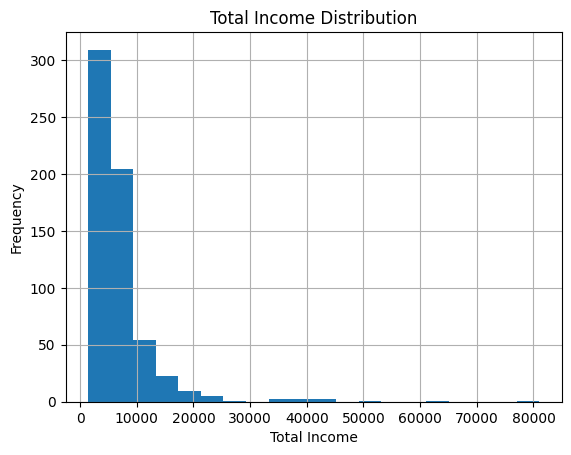

In [34]:
import matplotlib.pyplot as plt

data['Total_Income'].hist(bins=20)

plt.xlabel('Total Income')
plt.ylabel('Frequency')
plt.title('Total Income Distribution')
plt.show()

In [35]:
data.head()

,Customer_ID,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income,Total_Income_Log
0,569,Female,No,0,Graduate,No,2378,0.0,9,-inf,1,Urban,N,2378.0,7.774015
1,15,Male,Yes,2,Graduate,No,1299,1086.0,17,6.990257,1,Urban,Y,2385.0,7.776954
2,95,Male,No,0,Not Graduate,No,3620,0.0,25,-inf,1,Semiurban,Y,3620.0,8.194229
3,134,Male,Yes,0,Graduate,Yes,3459,0.0,25,-inf,1,Semiurban,Y,3459.0,8.148735
4,556,Male,Yes,1,Graduate,No,5468,1032.0,26,6.939254,1,Semiurban,Y,6500.0,8.779557


In [36]:
x = data.iloc[:, r_[1:5, 9:11, 13:15]].values
y = data.iloc[:, 12].values

In [37]:
x

array([['Female', 'No', 0, ..., 1, 2378.0, 7.774015077250727],
       ['Male', 'Yes', 2, ..., 1, 2385.0, 7.776954403322442],
       ['Male', 'No', 0, ..., 1, 3620.0, 8.194229304819817],
       ...,
       ['Male', 'Yes', 2, ..., 0, 6633.0, 8.799812469525556],
       ['Male', 'Yes', 1, ..., 1, 4867.0, 8.490233009833455],
       ['Male', 'Yes', 0, ..., 1, 6200.0, 8.732304571033183]],
      shape=(614, 8), dtype=object)

In [38]:
y

array(['N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'N', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'N', 'N',
       'N', 'N', 'Y', 'N', 'Y', 'N', 'N', 'Y', 'N', 'Y', 'Y', 'Y', 'Y',
       'N', 'N', 'Y', 'Y', 'Y', 'Y', 'N', 'N', 'Y', 'N', 'Y', 'N', 'Y',
       'Y', 'Y', 'Y', 'N', 'N', 'Y', 'Y', 'N', 'Y', 'Y', 'N', 'N', 'N',
       'Y', 'Y', 'Y', 'N', 'N', 'N', 'N', 'N', 'Y', 'Y', 'Y', 'Y', 'Y',
       'N', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N',
       'Y', 'N', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y',
       'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'N', 'Y',
       'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'N', 'N', 'Y', 'N', 'Y', 'Y',
       'Y', 'Y', 'N', 'N', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y',
       'N', 'Y', 'N', 'Y', 'N', 'N', 'Y', 'Y', 'Y', 'N', 'N', 'Y', 'Y',
       'N', 'N', 'Y', 'N', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y

In [39]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test= train_test_split(x,y,test_size=0.2,random_state=0)

In [40]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(491, 8)
(123, 8)
(491,)
(123,)


In [41]:
x_train

array([['Male', 'Yes', 1, ..., 1, 18917.0, 9.847816267665664],
       ['Male', 'Yes', 2, ..., 1, 21600.0, 9.980448593672257],
       ['Male', 'No', 0, ..., 1, 7977.0, 8.984317679911129],
       ...,
       ['Male', 'Yes', 0, ..., 1, 5829.0, 8.67060073804555],
       ['Male', 'Yes', 2, ..., 1, 4652.0, 8.445052513638554],
       ['Male', 'Yes', 4, ..., 1, 11750.0, 9.371608519572305]],
      shape=(491, 8), dtype=object)

In [42]:
y_train

array(['Y', 'N', 'Y', 'Y', 'N', 'N', 'Y', 'Y', 'N', 'Y', 'N', 'N', 'Y',
       'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y',
       'N', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N',
       'N', 'Y', 'Y', 'N', 'Y', 'Y', 'N', 'N', 'N', 'Y', 'Y', 'N', 'N',
       'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'N', 'Y', 'N', 'Y', 'Y',
       'N', 'Y', 'Y', 'Y', 'N', 'N', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'Y',
       'N', 'Y', 'Y', 'Y', 'Y', 'N', 'N', 'N', 'N', 'Y', 'N', 'Y', 'Y',
       'Y', 'N', 'Y', 'N', 'N', 'N', 'N', 'Y', 'Y', 'N', 'Y', 'N', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'N', 'Y', 'N', 'Y', 'Y', 'N',
       'N', 'N', 'N', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y',
       'Y', 'N', 'Y', 'Y', 'Y', 'N', 'N', 'Y', 'Y', 'N', 'Y', 'N', 'Y',
       'N', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y',
       'N', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'N', 'Y', 'Y', 'Y', 'Y

In [43]:
x_test

array([['Male', 'Yes', 0, 'Graduate', 7.851271997109883, 1, 6277.0,
        8.744647438317532],
       ['Male', 'Yes', 4, 'Not Graduate', 7.416979621381154, 0, 4611.0,
        8.436200032206706],
       ['Male', 'Yes', 2, 'Graduate', 8.392989587956931, 1, 7926.0,
        8.97790377375038],
       ['Male', 'Yes', 0, 'Graduate', 7.513709247839705, 1, 9734.0,
        9.1833801903934],
       ['Female', 'No', 0, 'Not Graduate', -inf, 1, 2165.0,
        7.68017564043659],
       ['Male', 'Yes', 0, 'Graduate', -inf, 1, 4600.0, 8.433811582477187],
       ['Male', 'Yes', 1, 'Graduate', 7.602900462204755, 1, 8069.0,
        8.995784837848506],
       ['Male', 'Yes', 1, 'Not Graduate', 7.265429723253953, 0, 6715.0,
        8.812099108957337],
       ['Male', 'No', 0, 'Graduate', -inf, 1, 6000.0, 8.699514748210191],
       ['Male', 'No', 0, 'Graduate', 7.557472901614746, 1, 6598.0,
        8.794521851788527],
       ['Male', 'No', 0, 'Graduate', -inf, 0, 4917.0, 8.50045386741194],
       ['Male',

In [44]:
y_test

array(['N', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y',
       'N', 'Y', 'N', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'N', 'N', 'Y', 'Y',
       'N', 'N', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'N', 'N', 'Y',
       'Y', 'N', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'N', 'Y', 'Y', 'N', 'Y', 'Y',
       'Y', 'Y', 'N', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y',
       'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N',
       'N', 'Y', 'Y', 'N', 'Y', 'N', 'N', 'Y', 'N', 'Y', 'Y', 'N', 'Y',
       'Y', 'Y', 'Y', 'Y', 'N', 'Y'], dtype=object)

In [45]:
from sklearn.preprocessing import LabelEncoder
LabelEncoder_x=LabelEncoder()

In [46]:
for i in range(0,5):
    x_train[:,i]=LabelEncoder_x.fit_transform(x_train[:,i])

In [47]:
x_train[:,7]=LabelEncoder_x.fit_transform(x_train[:,7])

In [48]:
x_train

array([[1, 1, 1, ..., 1, 18917.0, 429],
       [1, 1, 2, ..., 1, 21600.0, 433],
       [1, 0, 0, ..., 1, 7977.0, 343],
       ...,
       [1, 1, 0, ..., 1, 5829.0, 254],
       [1, 1, 2, ..., 1, 4652.0, 153],
       [1, 1, 3, ..., 1, 11750.0, 400]], shape=(491, 8), dtype=object)

In [49]:
LabelEncoder_y=LabelEncoder()
y_train=LabelEncoder_y.fit_transform(y_train)

In [50]:
y_train

array([1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0,
       1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0,
       1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1,
       1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1,

In [51]:
for i in range(0,5):
    x_test[:,i]=LabelEncoder_x.fit_transform(x_test[:,i])

In [52]:
x_test[:,7]=LabelEncoder_x.fit_transform(x_test[:,7])

In [53]:
x_test

array([[1, 1, 0, 0, 47, 1, 6277.0, 78],
       [1, 1, 3, 1, 20, 0, 4611.0, 42],
       [1, 1, 2, 0, 60, 1, 7926.0, 93],
       [1, 1, 0, 0, 24, 1, 9734.0, 104],
       [0, 0, 0, 1, 0, 1, 2165.0, 1],
       [1, 1, 0, 0, 0, 1, 4600.0, 41],
       [1, 1, 1, 0, 33, 1, 8069.0, 95],
       [1, 1, 1, 1, 12, 0, 6715.0, 86],
       [1, 0, 0, 0, 0, 1, 6000.0, 69],
       [1, 0, 0, 0, 27, 1, 6598.0, 85],
       [1, 0, 0, 0, 0, 0, 4917.0, 51],
       [1, 1, 0, 0, 0, 1, 9328.0, 98],
       [0, 0, 0, 0, 0, 1, 4547.0, 37],
       [1, 1, 1, 1, 62, 1, 9352.0, 99],
       [1, 1, 3, 0, 23, 0, 6144.0, 73],
       [0, 0, 2, 0, 0, 1, 3427.0, 15],
       [1, 1, 0, 0, 52, 1, 6274.0, 76],
       [1, 1, 0, 0, 39, 1, 4843.0, 49],
       [1, 1, 0, 0, 54, 1, 6873.0, 88],
       [1, 1, 0, 0, 0, 1, 7933.0, 94],
       [1, 1, 2, 0, 4, 1, 3900.0, 23],
       [1, 0, 0, 0, 50, 1, 6099.0, 72],
       [1, 0, 0, 0, 0, 0, 6277.0, 78],
       [1, 1, 2, 1, 0, 1, 4735.0, 47],
       [1, 1, 3, 0, 9, 1, 5666.0, 64],
       [1, 1

In [54]:
LabelEncoder_y=LabelEncoder()
y_test= LabelEncoder_y.fit_transform(y_test)

In [55]:
x_test

array([[1, 1, 0, 0, 47, 1, 6277.0, 78],
       [1, 1, 3, 1, 20, 0, 4611.0, 42],
       [1, 1, 2, 0, 60, 1, 7926.0, 93],
       [1, 1, 0, 0, 24, 1, 9734.0, 104],
       [0, 0, 0, 1, 0, 1, 2165.0, 1],
       [1, 1, 0, 0, 0, 1, 4600.0, 41],
       [1, 1, 1, 0, 33, 1, 8069.0, 95],
       [1, 1, 1, 1, 12, 0, 6715.0, 86],
       [1, 0, 0, 0, 0, 1, 6000.0, 69],
       [1, 0, 0, 0, 27, 1, 6598.0, 85],
       [1, 0, 0, 0, 0, 0, 4917.0, 51],
       [1, 1, 0, 0, 0, 1, 9328.0, 98],
       [0, 0, 0, 0, 0, 1, 4547.0, 37],
       [1, 1, 1, 1, 62, 1, 9352.0, 99],
       [1, 1, 3, 0, 23, 0, 6144.0, 73],
       [0, 0, 2, 0, 0, 1, 3427.0, 15],
       [1, 1, 0, 0, 52, 1, 6274.0, 76],
       [1, 1, 0, 0, 39, 1, 4843.0, 49],
       [1, 1, 0, 0, 54, 1, 6873.0, 88],
       [1, 1, 0, 0, 0, 1, 7933.0, 94],
       [1, 1, 2, 0, 4, 1, 3900.0, 23],
       [1, 0, 0, 0, 50, 1, 6099.0, 72],
       [1, 0, 0, 0, 0, 0, 6277.0, 78],
       [1, 1, 2, 1, 0, 1, 4735.0, 47],
       [1, 1, 3, 0, 9, 1, 5666.0, 64],
       [1, 1

In [56]:
y_test

array([0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1])

In [57]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
x_train=ss.fit_transform(x_train)
x_test=ss.transform(x_test)

In [58]:
from sklearn.tree import DecisionTreeClassifier
DTClassifier=DecisionTreeClassifier(criterion='entropy',random_state=0)
DTClassifier.fit(x_train,y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [59]:
y_pred= DTClassifier.predict(x_test)
y_pred

array([1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1])

In [60]:
from sklearn import metrics
print('The accuracy of the Decision Tree Classifier is:',metrics.accuracy_score(y_pred,y_test))

The accuracy of the Decision Tree Classifier is: 0.7154471544715447


In [61]:
from sklearn.naive_bayes import GaussianNB
NBClassifier=GaussianNB()
NBClassifier.fit(x_train,y_train)

,priors,None
,var_smoothing,1e-09


In [62]:
y_pred= NBClassifier.predict(x_test)
y_pred

array([1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1])

In [63]:
from sklearn import metrics
print('The accuracy of the Naive Bayes Classifier is:',metrics.accuracy_score(y_pred,y_test))

The accuracy of the Naive Bayes Classifier is: 0.8211382113821138


In [64]:
testdata=pd.read_csv('testdata.csv')

In [65]:
testdata.head()

,Customer_ID,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Property_Area
0,569,Female,No,0,Graduate,No,2378,0.0,9,360,1,Urban
1,15,Male,Yes,2,Graduate,No,1299,1086.0,17,120,1,Urban
2,95,Male,No,0,Not Graduate,No,3620,0.0,25,120,1,Semiurban
3,134,Male,Yes,0,Graduate,Yes,3459,0.0,25,120,1,Semiurban
4,556,Male,Yes,1,Graduate,No,5468,1032.0,26,360,1,Semiurban


In [66]:
testdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         614 non-null    int64  
 1   Gender              614 non-null    object 
 2   Married             614 non-null    object 
 3   Dependents          614 non-null    int64  
 4   Education           614 non-null    object 
 5   Self_Employed       614 non-null    object 
 6   Applicant_Income    614 non-null    int64  
 7   Coapplicant_Income  614 non-null    float64
 8   Loan_Amount         614 non-null    int64  
 9   Loan_Amount_Term    614 non-null    int64  
 10  Credit_History      614 non-null    int64  
 11  Property_Area       614 non-null    object 
dtypes: float64(1), int64(6), object(5)
memory usage: 57.7+ KB


In [67]:
testdata.isnull().sum()

Customer_ID           0
Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
Applicant_Income      0
Coapplicant_Income    0
Loan_Amount           0
Loan_Amount_Term      0
Credit_History        0
Property_Area         0
dtype: int64

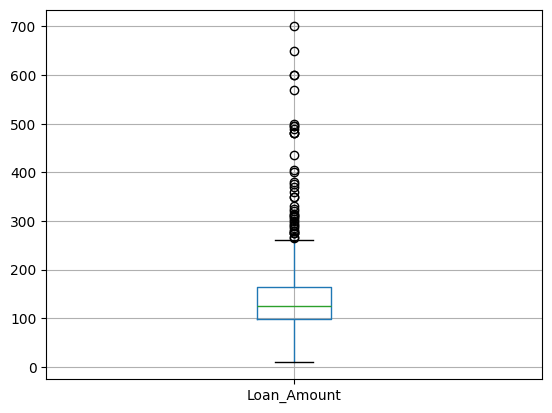

In [68]:
testdata.boxplot(column='Loan_Amount')
plt.show()

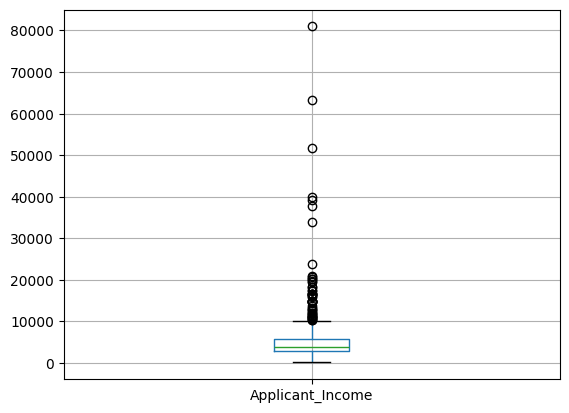

In [69]:
testdata.boxplot(column='Applicant_Income')
plt.show()

In [70]:
testdata.Loan_Amount=testdata.Loan_Amount.fillna(testdata.Loan_Amount.mean())
testdata['Loan_Amount_Log']=np.log(testdata['Loan_Amount'])

In [71]:
testdata.isnull().sum()

Customer_ID           0
Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
Applicant_Income      0
Coapplicant_Income    0
Loan_Amount           0
Loan_Amount_Term      0
Credit_History        0
Property_Area         0
Loan_Amount_Log       0
dtype: int64

In [81]:
testdata['Total_Income']=testdata['Applicant_Income']+testdata['Coapplicant_Income']
testdata['Total_Income_Log']=np.log(testdata['Total_Income'])

In [82]:
test= testdata.iloc[:,np.r_[1:5,9:11,13:15]].values

In [83]:
for i in range(0,5):
    test[:,i]=LabelEncoder_x.fit_transform(test[:,i])

In [76]:
test

array([[0, 0, 0, ..., 1, 2378.0, 7.774015077250727],
       [1, 1, 2, ..., 1, 2385.0, 7.776954403322442],
       [1, 0, 0, ..., 1, 3620.0, 8.194229304819817],
       ...,
       [1, 1, 2, ..., 0, 6633.0, 8.799812469525556],
       [1, 1, 1, ..., 1, 4867.0, 8.490233009833455],
       [1, 1, 0, ..., 1, 6200.0, 8.732304571033183]],
      shape=(614, 8), dtype=object)

In [77]:
test= ss.fit_transform(test)

In [78]:
pred=NBClassifier.predict(test)

In [79]:
pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1,
       1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1,

In [80]:
#0=the customer is not eligible for loan
#1=the customer is eligible for loan